In [ ]:
import collections
import importlib
import math
from pathlib import Path
from typing import Callable, Dict, Optional, Sequence, Tuple, Union

import numpy as np
import torch
import torch.nn as nn
import torchvision
from diffusers.optimization import get_scheduler
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.training_utils import EMAModel
from rich import print
from tqdm.auto import tqdm

/home/thankgod/2025/msc_project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
import sys

src_parent = os.path.abspath(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(src_parent)

import scripts
from scripts.image_dataset import PushTImageDataset, normalize_data, unnormalize_data
from scripts.model_config import TrainingConfig
from scripts.models import ConditionalUnet1D, VisionEncoder
from scripts.pusht_image_env import PushTImageEnv
from scripts.training_Inference import UnetTrainer


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/thankgod/2025/msc_project/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
dataset_path = Path.cwd().parent / "data/low_dim_pusht" / "replay_buffer.zarr"

# parameters
pred_horizon = 16
obs_horizon = 2
action_horizon = 8
#|o|o|                             observations: 2
#| |a|a|a|a|a|a|a|a|               actions executed: 8
#|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p|p| actions predicted: 16

# create dataset from file
dataset = PushTImageDataset(
    dataset_path=dataset_path,
    pred_horizon=pred_horizon,
    obs_horizon=obs_horizon,
    action_horizon=action_horizon
)
# save training data statistics (min, max) for each dim
stats = dataset.stats

# create dataloader
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    num_workers=4,
    shuffle=True,
    # accelerate cpu-gpu transfer
    pin_memory=True,
    # don't kill worker process afte each epoch
    persistent_workers=True
)

# visualize data in batch
batch = next(iter(dataloader))
print("batch['image'].shape:", batch['image'].shape)
print("batch['agent_pos'].shape:", batch['agent_pos'].shape)
print("batch['action'].shape", batch['action'].shape)

batch['image'].shape:
torch.Size([64, 2, 3, 96, 96])

batch['agent_pos'].shape:
torch.Size([64, 2, 2])

batch['action'].shape
torch.Size([64, 16, 2])

In [40]:
# Encoder
# resnet18 efficientnet_b0 mobilenet_v2 mobilenet_v3_small mobilenet_v3_large
encoder = VisionEncoder()
vision_encoder, vision_feature_dim = encoder.get_model("resnet18")


In [41]:

# Example Input: Define the observation and agent position tensors
image = torch.zeros((1, obs_horizon, 3, 96, 96))
agent_pos = torch.zeros((1, obs_horizon, 2))
lowdim_obs_dim = agent_pos.shape[-1] # agent_pos is 2 dimensional
# observation feature depends on the selected model output
obs_dim = vision_feature_dim + lowdim_obs_dim
action_dim = 2

In [42]:
# Unet
noise_pred_net = ConditionalUnet1D(
    input_dim=action_dim,  # input_dim (action_dim)
    global_cond_dim=obs_dim * obs_horizon,  # obs_dim=(512 + 2) * obs_horizon=2 -> 1028
)

nets = nn.ModuleDict({
    'vision_encoder': vision_encoder,
    'noise_pred_net': noise_pred_net
})

print(sum(p.numel() for p in nets.parameters()))

number of parameters 7.994727e+07


91123778

In [43]:

# Define the path
path = os.path.join(os.path.dirname(os.getcwd()), 'saved_models')
checkpoint_name = os.path.join(path, "Resnet_unet_100_model_checkpoint.pth")

# Load the state dictionary
state_dict = torch.load(checkpoint_name)

# Load the state dictionary into the model
nets.load_state_dict(state_dict)

# If you want to use the model for inference, set it to evaluation mode
nets.eval()

ModuleDict(
  (vision_encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): GroupNorm(4, 64, eps=1e-05, affine=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): GroupNorm(4, 64, eps=1e-05, affine=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): GroupNorm(4, 64, eps=1e-05, affine=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): GroupNorm(4, 64, eps=1e-05, affine=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)

In [44]:
# 0. create env object
env = PushTImageEnv()

# 1. seed env for initial state.
# Seed 0-200 are used for the demonstration dataset.
env.seed(1000)

# 2. must reset before use
obs, info = env.reset()

# 3. 2D positional action space [0,512]
action = env.action_space.sample()

# 4. Standard gym step method
obs, reward, terminated, truncated, info = env.step(action)

# prints and explains each dimension of the observation and action vectors
with np.printoptions(precision=4, suppress=True, threshold=5):
    print("obs['image'].shape:", obs['image'].shape, "float32, [0,1]")
    print("obs['agent_pos'].shape:", obs['agent_pos'].shape, "float32, [0,512]")
    print("action.shape: ", action.shape, "float32, [0,512]")

obs['image'].shape:
(3, 96, 96)
float32, [0,1]

obs['agent_pos'].shape:
(2,)
float32, [0,512]

action.shape: 
(2,)
float32, [0,512]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

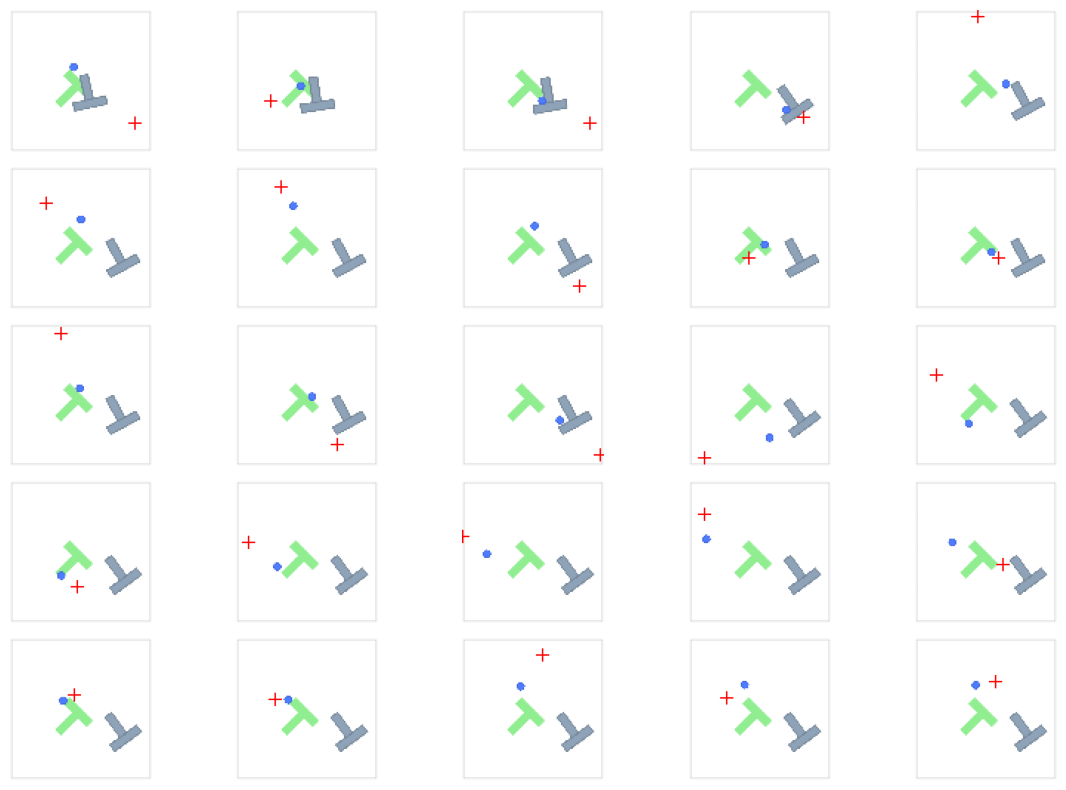

In [46]:
def plot_image_grid(images, rows, cols, figsize=(12, 8)):
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(images):
            ax.imshow(images[i])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

frames = []

obs, info = env.reset()

for _ in range(100):
    action = env.action_space.sample()  # random action
    obs, reward, terminated, truncated, info = env.step(action)
    frames.append(env.render(mode="rgb_array"))

    if terminated or truncated:
        obs, info = env.reset()

env.close()

# Example: 5 rows × 5 columns = 25 images
plot_image_grid(frames, rows=5, cols=5)


In [13]:
obs, info = env.reset()
print(obs)

{
    'image': array([[[1.        , 0.972549  , 0.972549  , ..., 0.972549  ,
         0.972549  , 1.        ],
        [0.972549  , 0.87058824, 0.9137255 , ..., 0.9137255 ,
         0.87058824, 0.972549  ],
        [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
         0.9137255 , 0.96862745],
        ...,
        [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
         0.9137255 , 0.96862745],
        [0.972549  , 0.87058824, 0.9137255 , ..., 0.9137255 ,
         0.87058824, 0.972549  ],
        [1.        , 0.972549  , 0.972549  , ..., 0.972549  ,
         0.972549  , 1.        ]],

       [[1.        , 0.972549  , 0.972549  , ..., 0.972549  ,
         0.972549  , 1.        ],
        [0.972549  , 0.87058824, 0.9137255 , ..., 0.9137255 ,
         0.87058824, 0.972549  ],
        [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
         0.9137255 , 0.96862745],
        ...,
        [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
         0.9137255 , 0.96862745],
        [0.972549  , 0.87058824, 0.9137255 , ..., 0.9137255 ,
         0.87058824, 0.972549  ],
        [1.        , 0.972549  , 0.972549  , ..., 0.972549  ,
         0.972549  , 1.        ]],

       [[1.        , 0.972549  , 0.972549  , ..., 0.972549  ,
         0.972549  , 1.        ],
        [0.972549  , 0.87058824, 0.9137255 , ..., 0.9137255 ,
         0.87058824, 0.972549  ],
        [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
         0.9137255 , 0.96862745],
        ...,
        [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
         0.9137255 , 0.96862745],
        [0.972549  , 0.87058824, 0.9137255 , ..., 0.9137255 ,
         0.87058824, 0.972549  ],
        [1.        , 0.972549  , 0.972549  , ..., 0.972549  ,
         0.972549  , 1.        ]]], dtype=float32),
    'agent_pos': array([137., 121.])
}

In [48]:
nets,
max_steps: int = 500,
seed: int = 100000,
save_video: bool = True,
video_path: str = 'vis.mp4'
num_diffusion_iters = 100

In [49]:
# Setup environment
env.seed(seed)
obs, info = env.reset()

cfg = TrainingConfig()

# Instead of setup_training(), manually build required components
device = torch.device('cpu')

noise_scheduler = DDPMScheduler(  # or whatever scheduler you use
    num_train_timesteps=cfg.num_diffusion_iters
)

In [14]:
device

device(type='cpu')

In [50]:
# Infer action_dim from env
if hasattr(env.action_space, 'shape'):
    action_dim = env.action_space.shape[0]
else:
    action_dim = 2  # fallback

In [51]:
# Keep recent observations
obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)

imgs = [env.render(mode='rgb_array')] if save_video else []
rewards = []
done = False
step_idx = 0

In [52]:
images = np.stack([x['image'] for x in obs_deque]) #(2, 3, 96, 96)
agent_poses = np.stack([x['agent_pos'] for x in obs_deque]) #(2, 2)

# normalize agent actions, observations already n
nagent_poses = normalize_data(agent_poses, stats=stats['agent_pos'])
nimages = images

# move observations and actions to torch
nimages = torch.from_numpy(nimages).to(device, dtype=torch.float32)
nagent_poses = torch.from_numpy(nagent_poses).to(device, dtype=torch.float32)

In [53]:
with torch.no_grad():
    image_features = nets['vision_encoder'](nimages)

image_features

tensor([[0.0525, 0.0022, 1.6380,  ..., 0.0078, 0.2651, 0.2682],
        [0.0525, 0.0022, 1.6380,  ..., 0.0078, 0.2651, 0.2682]])

In [54]:
nets['vision_encoder'].layer4[-1]

BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): GroupNorm(32, 512, eps=1e-05, affine=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): GroupNorm(32, 512, eps=1e-05, affine=True)
)

In [20]:
nimages[0]

tensor([[[1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000],
         [0.9725, 0.8706, 0.9137,  ..., 0.9137, 0.8706, 0.9725],
         [0.9686, 0.9137, 1.0000,  ..., 1.0000, 0.9137, 0.9686],
         ...,
         [0.9686, 0.9137, 1.0000,  ..., 1.0000, 0.9137, 0.9686],
         [0.9725, 0.8706, 0.9137,  ..., 0.9137, 0.8706, 0.9725],
         [1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000]],

        [[1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000],
         [0.9725, 0.8706, 0.9137,  ..., 0.9137, 0.8706, 0.9725],
         [0.9686, 0.9137, 1.0000,  ..., 1.0000, 0.9137, 0.9686],
         ...,
         [0.9686, 0.9137, 1.0000,  ..., 1.0000, 0.9137, 0.9686],
         [0.9725, 0.8706, 0.9137,  ..., 0.9137, 0.8706, 0.9725],
         [1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000]],

        [[1.0000, 0.9725, 0.9725,  ..., 0.9725, 0.9725, 1.0000],
         [0.9725, 0.8706, 0.9137,  ..., 0.9137, 0.8706, 0.9725],
         [0.9686, 0.9137, 1.0000,  ..., 1.0000, 0.9137, 0.

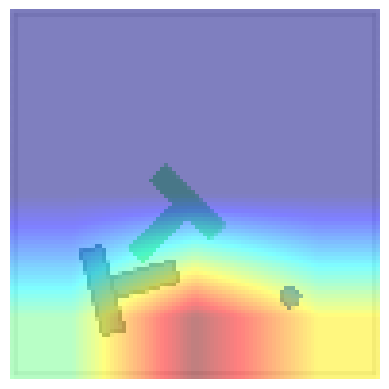

In [ ]:
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# target layer
target_layer = nets['vision_encoder'].layer4[-1]

cam = GradCAM(model=nets['vision_encoder'],
              target_layers=[target_layer])

# Take first image
image_test = nimages[0]  # shape: (3, H, W), already [0,1]

# Convert to numpy and HWC format
img_np = image_test.permute(1, 2, 0).cpu().numpy().astype(np.float32)

# Get grayscale CAM (shape: (H, W))
grayscale_cam = cam(input_tensor=image_test.unsqueeze(0), targets=None)[0]

# Overlay CAM on image
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

# Display
plt.imshow(visualization)
plt.axis('off')
plt.show()


In [31]:
len(predicted_actions_list)

13

In [33]:
predicted_actions_list[0].shape

(16, 2)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

# --- Main simulation ---
frames = []
predicted_actions_list = []

max_steps = 300
with tqdm(max_steps, desc="Eval PushTImageEnv") as pbar:
    while not done:
        B = 1
        images = np.stack([x['image'] for x in obs_deque])
        agent_poses = np.stack([x['agent_pos'] for x in obs_deque])

        nagent_poses = normalize_data(agent_poses, stats=stats['agent_pos'])
        nimages = images

        nimages = torch.from_numpy(nimages).to(device, dtype=torch.float32)
        nagent_poses = torch.from_numpy(nagent_poses).to(device, dtype=torch.float32)

        with torch.no_grad():
            image_features = nets['vision_encoder'](nimages)
            obs_features = torch.cat([image_features, nagent_poses], dim=-1)
            obs_cond = obs_features.unsqueeze(0).flatten(start_dim=1)

            noisy_action = torch.randn((B, pred_horizon, action_dim), device=device)
            naction = noisy_action

            noise_scheduler.set_timesteps(num_diffusion_iters)
            for k in noise_scheduler.timesteps:
                noise_pred = nets['noise_pred_net'](
                    sample=naction,
                    timestep=k,
                    global_cond=obs_cond
                )
                naction = noise_scheduler.step(
                    model_output=noise_pred,
                    timestep=k,
                    sample=naction
                ).prev_sample

            naction = naction.detach().to('cpu').numpy()[0]
            action_pred = unnormalize_data(naction, stats=stats['action'])

            start = obs_horizon - 1
            end = start + action_horizon
            action = action_pred[start:end, :] # receding horizon

            predicted_actions_list.append(action_pred) # store

        for i in range(len(action)): # iteratively apply action predictions
            obs, reward, done, _, info = env.step(action[i])
            obs_deque.append(obs)
            rewards.append(reward)

            # Instead of save_video → collect frames for grid
            frames.append(env.render(mode='rgb_array'))

            step_idx += 1
            pbar.update(1)
            pbar.set_postfix(reward=reward)

            if step_idx > max_steps:
                done = True
                break

        if done:
            break

score = max(rewards) if rewards else 0
print(f'Score: {score}')

Eval PushTImageEnv: 101it [00:27,  3.69it/s, reward=0.0599] 


Score: 0.059850304238776963

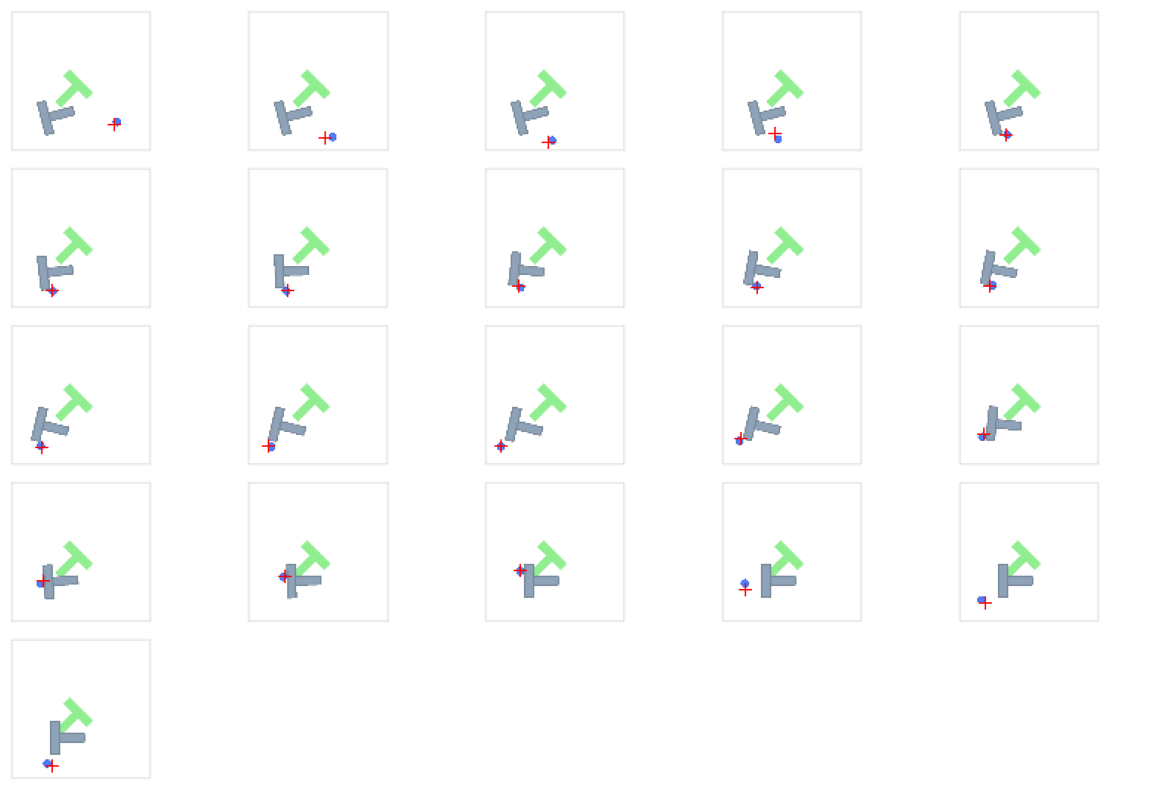

In [24]:
def plot_image_grid(images, rows, cols, step=1, figsize=(12, 8)):
    sampled = images[::step]
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(sampled):
            ax.imshow(sampled[i])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Example: take every 10th frame
plot_image_grid(frames, rows=5, cols=5, step=5)


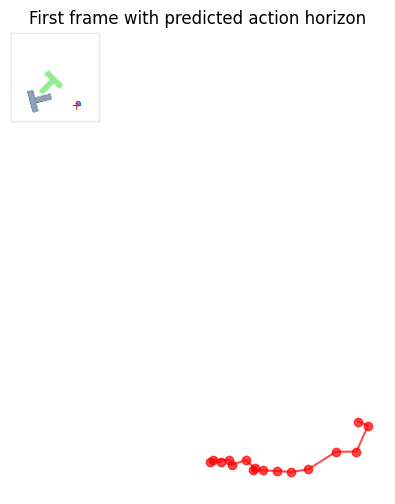

In [ ]:
def env_to_image_coords(actions, obs_image, env_bounds):
    """
    Convert environment coordinates to image pixel coordinates.
    
    actions: (horizon, 2) array of x,y in env coordinates
    obs_image: (H, W, C) numpy array
    env_bounds: ((x_min, x_max), (y_min, y_max)) environment limits
    """
    H, W = obs_image.shape[:2]
    (x_min, x_max), (y_min, y_max) = env_bounds

    # Normalize actions to [0,1] relative to env bounds
    x_norm = (actions[:, 0] - x_min) / (x_max - x_min)
    y_norm = (actions[:, 1] - y_min) / (y_max - y_min)

    # Convert to pixel coordinates
    px = x_norm * W
    py = H - y_norm * H  # flip y-axis because image origin is top-left

    return np.stack([px, py], axis=1)

scaled_coords = env_to_image_coords(16, first_frame, env_bounds=((0, 96), (0, 96)))
plt.figure(figsize=(6,6))
plt.imshow(first_frame)
plt.plot(scaled_coords[:,0], scaled_coords[:,1], marker='o', color='red', alpha=0.7)
plt.axis('off')
plt.show()


In [38]:
predicted_actions_list[0]

array([[367.1904 , 410.9065 ],
       [377.68784, 415.16476],
       [365.44238, 442.64398],
       [343.53696, 442.92038],
       [314.77454, 461.38037],
       [296.17783, 464.2459 ],
       [281.64514, 463.07117],
       [266.71893, 462.5801 ],
       [255.78275, 462.39743],
       [258.22656, 460.27826],
       [248.54077, 451.45496],
       [233.99257, 456.90085],
       [231.14812, 451.56244],
       [214.4191 , 451.2604 ],
       [222.89479, 453.60226],
       [211.20387, 453.87875]], dtype=float32)

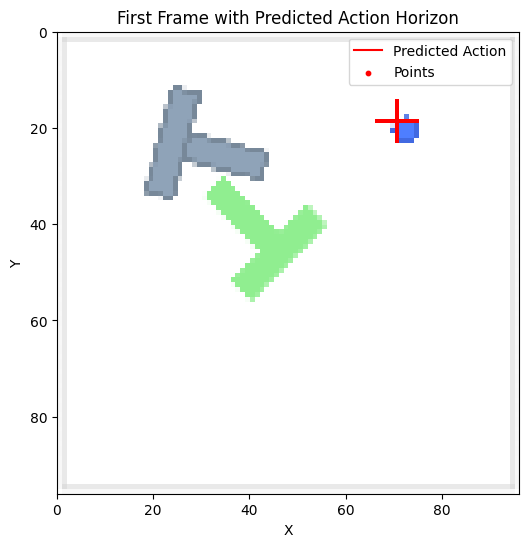

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np

# Assuming the observation frame is saved as a NumPy array or image
# Load the first observation frame (e.g., from a file or array)
observation_frame = frames[0]  # Replace with your loading logic
# Ensure it's 96x96 (grayscale or RGB)
if len(observation_frame.shape) == 2:  # Grayscale
    observation_frame = np.stack([observation_frame]*3, axis=-1)  # Convert to RGB for display
elif observation_frame.shape[-1] != 3:  # Ensure 3 channels
    observation_frame = np.stack([observation_frame[:,:,0]]*3, axis=-1)

# Load the first action sequence prediction (16, 2) array
action_sequence = predicted_actions_list[0]  # Replace with your loading logic
# Ensure it has shape (16, 2)
assert action_sequence.shape == (16, 2), "Action sequence must be (16, 2)"

# Create the plot
fig, ax = plt.subplots(figsize=(6, 6))  # Adjust figure size to match 96x96 aspect ratio

# Display the observation frame as the background
ax.imshow(observation_frame, extent=[0, 96, 0, 96])  # Set extent to match 96x96 frame

# Plot the action sequence
ax.plot(action_sequence[:, 0], action_sequence[:, 1], 'r-', label='Predicted Action')  # Line
ax.scatter(action_sequence[:, 0], action_sequence[:, 1], c='red', s=10, label='Points')  # Points

# Set labels and title
ax.set_title('First Frame with Predicted Action Horizon')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()

# Set the limits to match the 96x96 frame
ax.set_xlim(0, 96)
ax.set_ylim(0, 96)

# Invert y-axis to match image coordinates (top-left origin)
ax.invert_yaxis()

# Show the plot
plt.show()

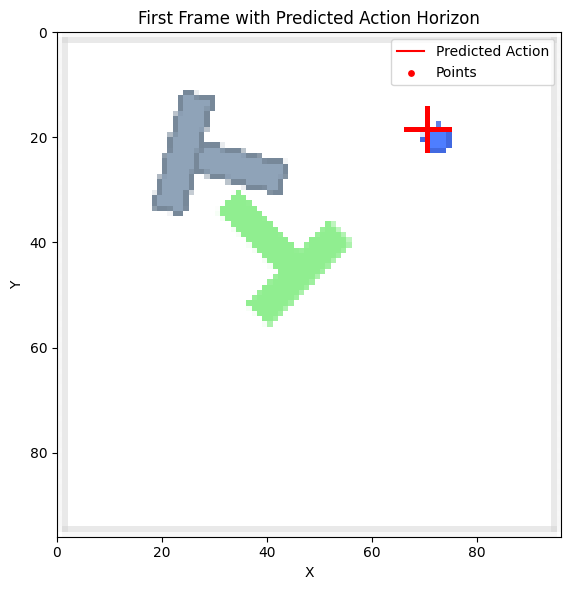

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

assert observation_frame.shape[:2] == (96, 96)
assert action_sequence.shape == (16, 2)

fig, ax = plt.subplots(figsize=(6, 6))

# Display the image
# Note: origin='upper' properly aligns the top-left origin typical in images
ax.imshow(observation_frame, extent=[0, 96, 0, 96], origin='upper')

# Plot the action sequence prediction
ax.plot(action_sequence[:, 0], action_sequence[:, 1], 'r-', label='Predicted Action')
ax.scatter(action_sequence[:, 0], action_sequence[:, 1], c='red', s=15, label='Points')

# Axes limits and labels (ensure full image is visible)
ax.set_xlim(0, 96)
ax.set_ylim(96, 0)  # Y-axis inverted: 0 (top), 96 (bottom)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('First Frame with Predicted Action Horizon')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
def run_inference(
    ema_nets,
    max_steps: int = 500,
    seed: int = 100000,
    save_video: bool = True,
    video_path: str = 'vis.mp4'
):
    """
    Run inference using the trained diffusion policy (no W&B logging).
    """
    # No wandb.init() here

    # Setup environment
    env.seed(seed)
    obs, info = env.reset()

    cfg = TrainingConfig()

    # Instead of setup_training(), manually build required components
    device = torch.device(cfg.device)
    noise_scheduler = DDPMScheduler(  # or whatever scheduler you use
        num_train_timesteps=cfg.num_diffusion_iters
    )

    obs_horizon = cfg.obs_horizon
    pred_horizon = cfg.pred_horizon
    action_horizon = cfg.action_horizon

    # Infer action_dim from env
    if hasattr(env.action_space, 'shape'):
        action_dim = env.action_space.shape[0]
    else:
        action_dim = 2  # fallback

    # Keep recent observations
    obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)

    imgs = [env.render(mode='rgb_array')] if save_video else []
    rewards = []
    done = False
    step_idx = 0

    with tqdm(total=max_steps, desc="Eval PushTImageEnv") as pbar:
        while not done:
            B = 1
            images = np.stack([x['image'] for x in obs_deque])
            agent_poses = np.stack([x['agent_pos'] for x in obs_deque])

            nagent_poses = normalize_data(agent_poses, stats=stats['agent_pos'])
            nimages = images

            nimages = torch.from_numpy(nimages).to(device, dtype=torch.float32)
            nagent_poses = torch.from_numpy(nagent_poses).to(device, dtype=torch.float32)

            with torch.no_grad():
                image_features = ema_nets['vision_encoder'](nimages)
                obs_features = torch.cat([image_features, nagent_poses], dim=-1)
                obs_cond = obs_features.unsqueeze(0).flatten(start_dim=1)

                noisy_action = torch.randn((B, pred_horizon, action_dim), device=device)
                naction = noisy_action

                noise_scheduler.set_timesteps(cfg.num_diffusion_iters)
                for k in noise_scheduler.timesteps:
                    noise_pred = ema_nets['noise_pred_net'](
                        sample=naction,
                        timestep=k,
                        global_cond=obs_cond
                    )
                    naction = noise_scheduler.step(
                        model_output=noise_pred,
                        timestep=k,
                        sample=naction
                    ).prev_sample

                naction = naction.detach().to('cpu').numpy()[0]
                action_pred = unnormalize_data(naction, stats=stats['action'])

                start = obs_horizon - 1
                end = start + action_horizon
                action = action_pred[start:end, :]

            for i in range(len(action)):
                obs, reward, done, _, info = env.step(action[i])
                obs_deque.append(obs)
                rewards.append(reward)
                if save_video:
                    imgs.append(env.render(mode='rgb_array'))
                step_idx += 1
                pbar.update(1)
                pbar.set_postfix(reward=reward)
                if step_idx > max_steps:
                    done = True
                    break

            if done:
                break

    score = max(rewards) if rewards else 0
    print(f'Score: {score}')

    if save_video and imgs:
        try:
            vwrite(video_path, imgs)
            Video(video_path, embed=True, width=256, height=256)
            print(f"Video saved to: {video_path}")
        except Exception as e:
            print(f"Error saving video: {e}")

run_inference(ema_nets)